Total crops: 63 | will label first 30


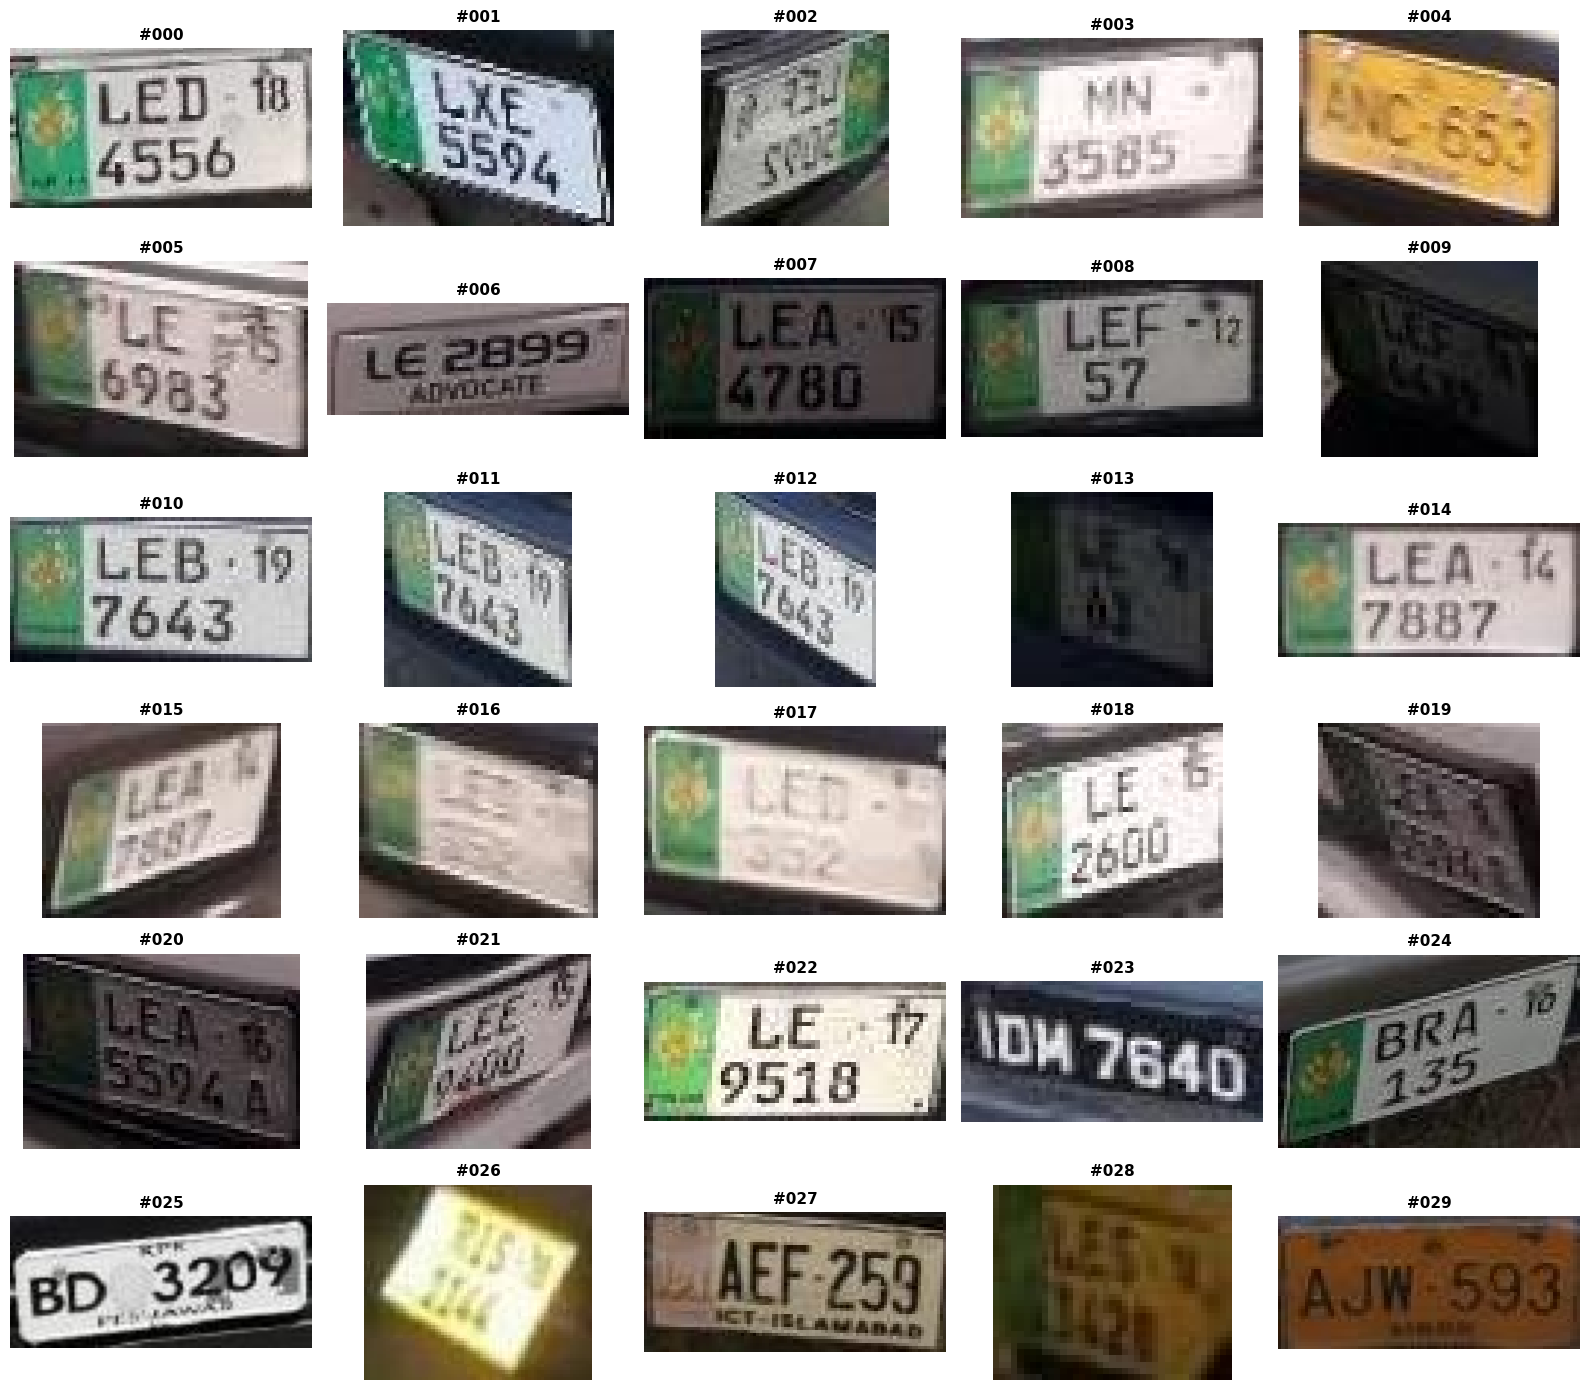

In [4]:
"""Show the first 30 crops in a numbered grid for manual ground-truth labeling.
Each crop title shows the crop_id — type the text into the CSV for that ID."""

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CROP_DIR = PROJECT_ROOT / "data" / "processed" / "test_crops"
CSV_PATH = CROP_DIR / "_ground_truth.csv"

# Force crop_id to stay a zero-padded 3-digit string (matches the filenames on disk)
df = pd.read_csv(CSV_PATH, dtype={"crop_id": str})
df["crop_id"] = df["crop_id"].str.zfill(3)
print(f"Total crops: {len(df)} | will label first 30")

N = 30
fig, axes = plt.subplots(6, 5, figsize=(16, 14))
for ax, (_, row) in zip(axes.flat, df.head(N).iterrows()):
    crop_name = next(CROP_DIR.glob(f"{row['crop_id']}__*.jpg"), None)
    if crop_name:
        ax.imshow(Image.open(crop_name))
    else:
        ax.text(0.5, 0.5, "NOT FOUND", ha="center", va="center", color="red")
    ax.axis("off")
    ax.set_title(f"#{row['crop_id']}", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()